In [2]:
import pandas as pd

# pd.set_option('display.max_columns', None)  # none은 제한값 자리(몇개 열까지 보여줄까)
# pd.set_option('display.max_rows', None)

# 집
# train = pd.read_parquet(r'C:\Users\soohok402\내 드라이브\Github\AI_Data_exhibition\parqueted_data\train_split')
# val = pd.read_parquet(r'C:\Users\soohok402\내 드라이브\Github\AI_Data_exhibition\parqueted_data\val_split')

# 회사
train = pd.read_parquet(r'C:\Users\20162180\AI_Data_exhibition\parqueted_data\train_split')
val = pd.read_parquet(r'C:\Users\20162180\AI_Data_exhibition\parqueted_data\val_split')

In [3]:
# 컬럼 분리하기

# 시계열 컬럼군
time_cols = ['wl_t',          # 수위데이터 대표
        'sfc_rain_1h',   # 육상 누적강수데이터 대표
        'imerg_rain_1h', # 레이더 누적강수데이터 대표
        'radar_reflectivity_mean', # 레이더반사도 대표
        'radar_reflectivity_p95', # 레이더반사도 대표
        'target_maxrise_6h' # 종속변수: 수위상승량
]

# 수위 컬럼군
wl_cols = ['wl_t',
          'wl_t_minus_1h',
          'wl_t_minus_3h',
          'wl_t_minus_6h',
          'wl_t_minus_12h',
          'wl_t_minus_24h',
          'target_maxrise_6h',
]

# 강수 컬럼군
rain_cols = [
            # IMERG강우
            'imerg_rain_1h',
            'imerg_rain_6h',
            'imerg_rain_24h',
            # 지상강우
            'sfc_rain_1h',
            'sfc_rain_6h',
            'sfc_rain_24h',
            # 레이더 반사도
            'radar_reflectivity_mean',
            'radar_reflectivity_p95',
            'radar_reflectivity_ge20_fraction'
]

# 환경 컬럼군
env_cols = [
    'cat_area',       # km²
    'wsarea',         # km²
    'mean_elevation', # m
    'mean_slope',     # °
    'urban_ratio',    # %
    'forest_ratio',   # %
    'stream_order'
]

In [ ]:
# ======================================================================
# 1-1. (시계열) train, val 데이터 박스플롯, 히스토그램 비교하기: 분포 비교용
# ======================================================================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    len(time_cols),
    2,
    figsize = (12, 4 * len(time_cols))
)

if len(time_cols) == 1 :
    axes = [axes]

for i, col in enumerate(time_cols):
    tr = train[col].dropna()
    va = val[col].dropna()

    axes[i][0].boxplot([tr, va], tick_labels = ['Train', 'Validation'])
    axes[i][0].set_title(col, fontsize = 20)
    axes[i][0].tick_params(labelsize = 10)
    # 박스플롯은 x축에 이름이 적히므로 범례 필요없음

    axes[i][1].hist(tr, range = (min(tr.min(), va.min()), max(tr.max(), va.max())),
                    # range로 범위를 통일하지 않으면, 서로다른 범위를 bin만큼 쪼개므로 범위가 달라 분포도 바뀜
                    bins = 30, alpha = 0.5,  # 투명도(0이 완전 투명, 1이 완전불투명)
                    density = True,  # True는 두 데이터의 n이 다를때 전체 면적은 동일하게 만들어 비교케 해줌
                    label = 'Train')
    axes[i][1].hist(va, range = (min(tr.min(), va.min()), max(tr.max(), va.max())),
                    bins = 30, alpha = 0.5,  # 투명도(0이 완전 투명, 1이 완전불투명)
                    density = True,  # True는 두 데이터의 n이 다를때 전체 면적은 동일하게 만들어 비교케 해줌
                    label = 'Validation')
    axes[i][1].set_title(col, fontsize = 20)
    axes[i][1].tick_params(labelsize = 10)
    axes[i][1].legend()  # 범례

plt.tight_layout()
plt.show()

In [7]:
# ============================================================
# 1-2. (시계열) 기초통계량 비교: 시계열데이터 전부 다 비교
# ============================================================

for col in (wl_cols + rain_cols):
    print(col)
    print(pd.concat(
        [
        train[col].quantile([0.5, 0.75, 0.9, 0.95, 0.99, 1.0]),
        val[col].quantile([0.5, 0.75, 0.9, 0.95, 0.99, 1.0])
        ],
        axis = 1,  # 가로로 붙이기
        keys = ['Train', 'Validation']  # 시리즈는 columns가 아니라 keys로 명명
    ).to_csv(sep = '\t')  # 탭으로 구분된 csv로 변환
    )

    print()


wl_t
	Train	Validation
0.5	1.14	1.11
0.75	1.98	1.9
0.9	4.01	3.72
0.95	25.01	24.96
0.99	78.80699999999953	79.28
1.0	139.64	136.81


wl_t_minus_1h
	Train	Validation
0.5	1.13	1.1
0.75	1.97	1.89
0.9	3.99	3.71
0.95	25.01	24.96
0.99	78.80699999999953	79.28
1.0	139.69	136.77


wl_t_minus_3h
	Train	Validation
0.5	1.12	1.09
0.75	1.95	1.88
0.9	3.93	3.7
0.95	25.01	24.97
0.99	78.8	79.27760000000009
1.0	139.75	136.74


wl_t_minus_6h
	Train	Validation
0.5	1.1	1.08
0.75	1.92	1.87
0.9	3.86	3.7
0.95	25.01	24.98
0.99	78.8	79.27
1.0	139.9	136.63


wl_t_minus_12h
	Train	Validation
0.5	1.08	1.07
0.75	1.89	1.87
0.9	3.79	3.75
0.95	25.02	24.997999999999884
0.99	78.8	79.24
1.0	140.14	136.35


wl_t_minus_24h
	Train	Validation
0.5	1.06	1.06
0.75	1.87	1.87
0.9	3.76	3.75
0.95	25.03	25.0
0.99	78.79	79.21
1.0	140.58	135.53


target_maxrise_6h
	Train	Validation
0.5	0.01	0.01
0.75	0.07	0.06
0.9	0.28	0.24
0.95	0.58	0.51
0.99	1.94	1.56
1.0	8.3	7.71


imerg_rain_1h
	Train	Validation
0.5	0.25	0.142
0.75	1.5165	1.348
0.9	4

In [8]:
# imerg_rain_24h, sfc_rain_24h에서 상위 분위값에서 train, val간 차이 확인
# 두 변수는 강우사상별 1개 값으로 요약하여 비교
# (긴 시간대를 가진 강우사상은 통계치에 영향을 주므로 이를 배제하기 위함)

print('imerg_rain_24h')
print(pd.concat(
    [
    train.groupby('event_id')['imerg_rain_24h'].max().quantile([0.5, 0.75, 0.9, 0.95, 0.99, 1.0]),
    val.groupby('event_id')['imerg_rain_24h'].max().quantile([0.5, 0.75, 0.9, 0.95, 0.99, 1.0])
    ],
    axis = 1,
    keys = ['Train', 'Validation']
).to_csv(sep='\t')
)
print()

print('sfc_rain_24h')
print(pd.concat(
    [
    train.groupby('event_id')['sfc_rain_24h'].max().quantile([0.5, 0.75, 0.9, 0.95, 0.99, 1.0]),
    val.groupby('event_id')['sfc_rain_24h'].max().quantile([0.5, 0.75, 0.9, 0.95, 0.99, 1.0])
    ],
    axis = 1,
    keys = ['Train', 'Validation']
).to_csv(sep='\t')
)

imerg_rain_24h
	Train	Validation
0.5	43.565	63.70400000000001
0.75	79.71275	109.29425
0.9	129.21309999999997	141.23239999999998
0.95	172.8799999999993	154.02405
0.99	362.86466	160.29255
1.0	371.228	161.745


sfc_rain_24h
	Train	Validation
0.5	44.0	50.5
0.75	99.75	113.25
0.9	172.04999999999998	175.4
0.95	203.24999999999994	186.62499999999997
0.99	364.78000000000003	216.605
1.0	390.0	225.0



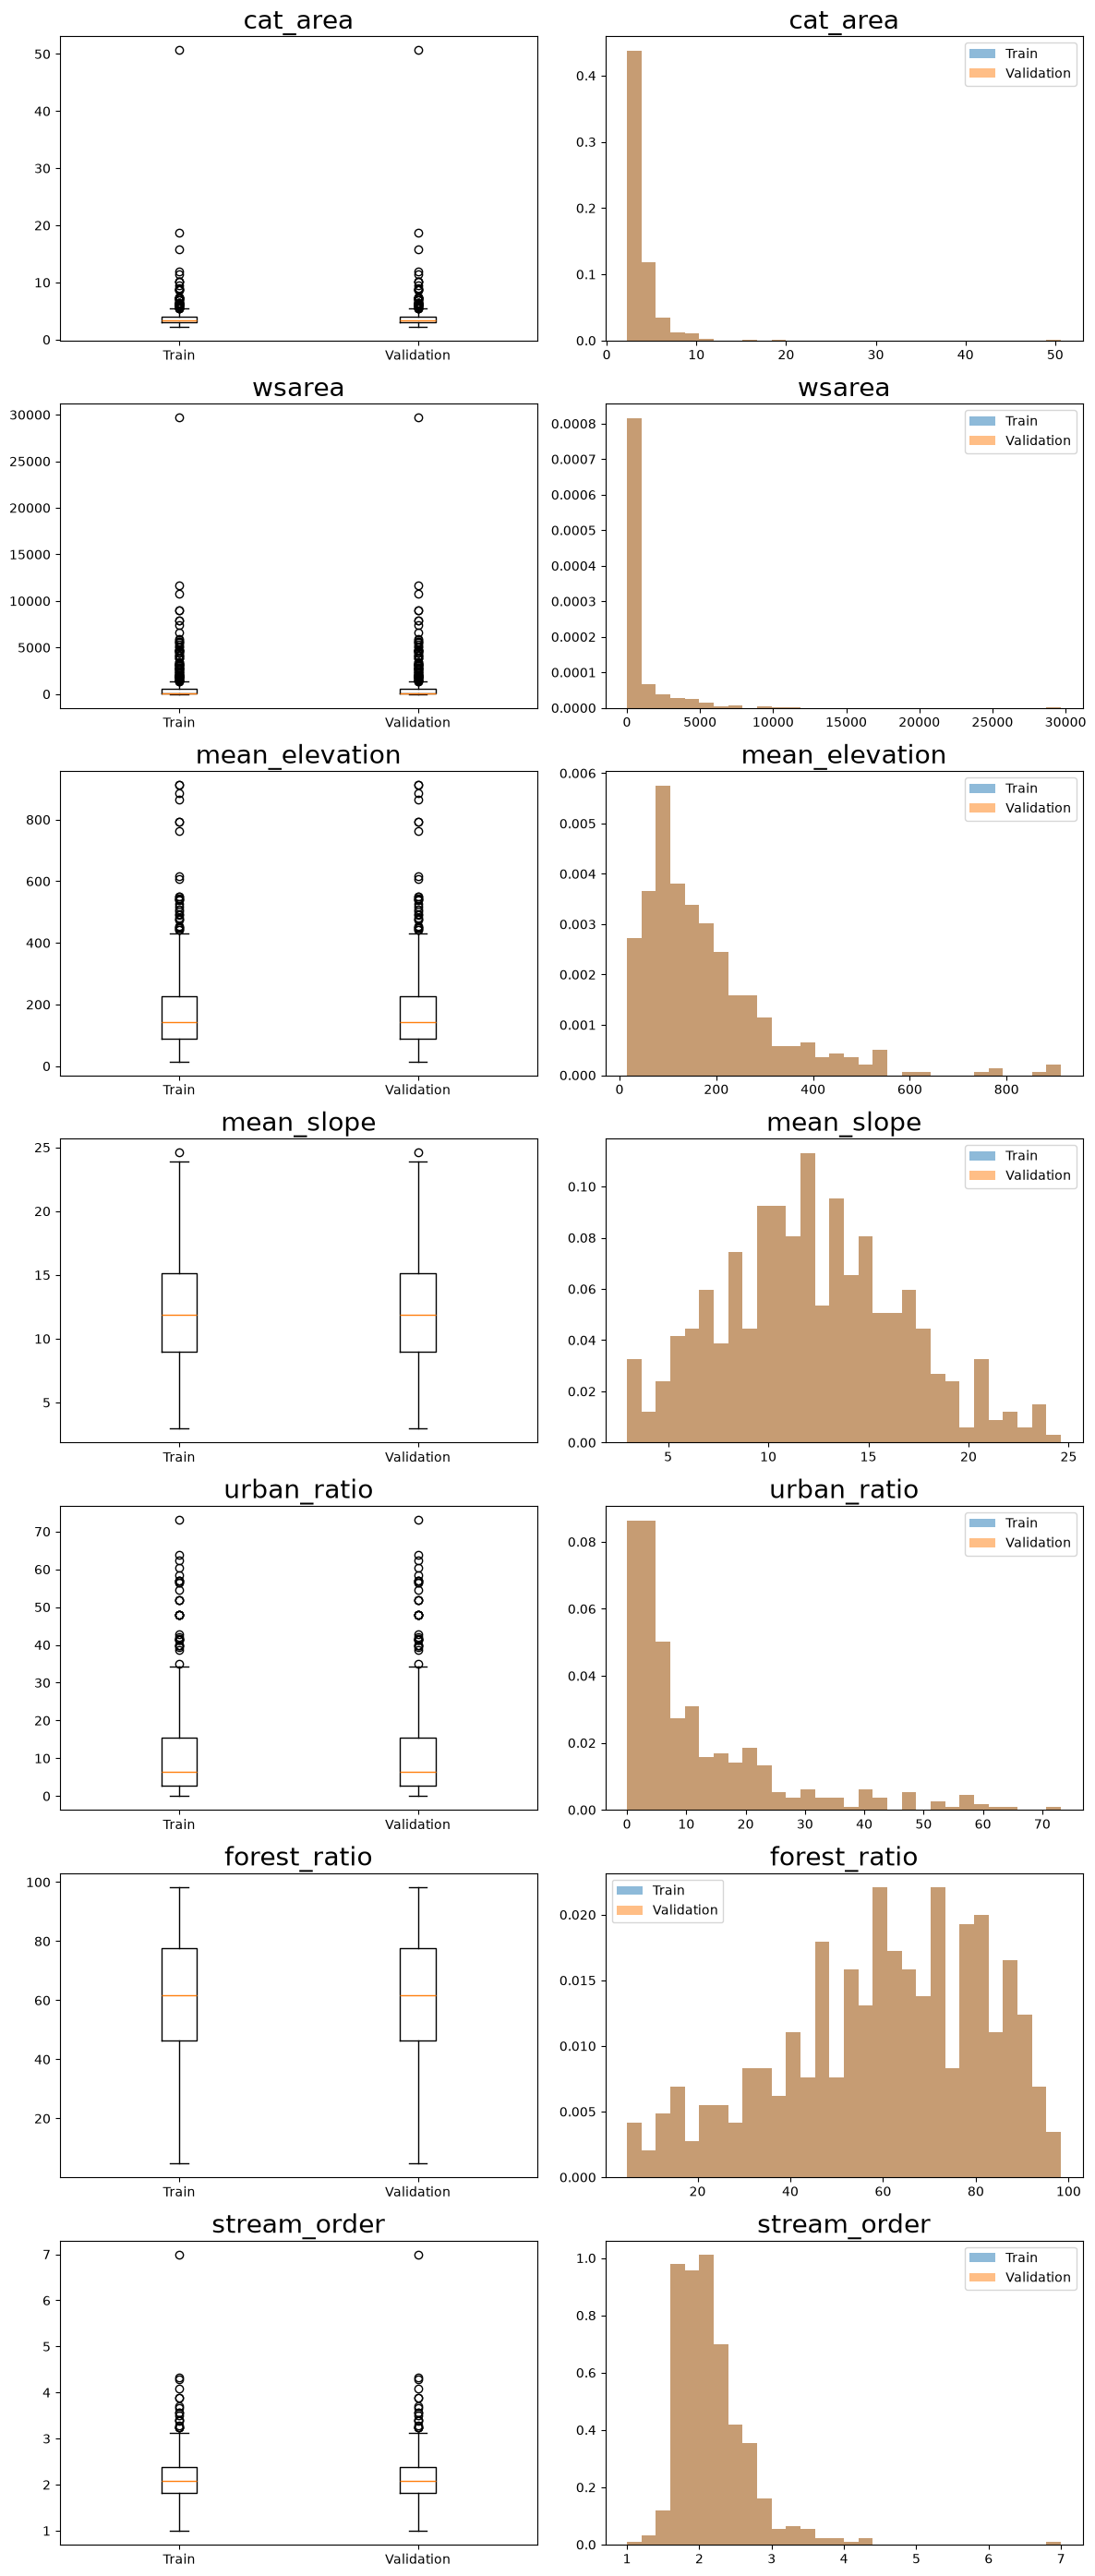

In [16]:
# =========================================================================
# 2-1. (환경데이터) train, val 데이터 박스플롯, 히스토그램 비교하기: 분포 비교용
# =========================================================================

# 환경데이터는 관측소별로 groupby 한 후에 박스플롯과 히스토그램 그리기

train_env_gb_df = train.groupby('station_id')[env_cols].first()
val_env_gb_df = val.groupby('station_id')[env_cols].first()

# display(train_env_gb_df)
# display(val_env_gb_df)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    len(env_cols),
    2,
    figsize = (12, 4 * len(env_cols))
)

if len(time_cols) == 1 :
    axes = [axes]

for i, col in enumerate(env_cols):
    tr = train_env_gb_df[col].dropna()
    va = val_env_gb_df[col].dropna()

    axes[i][0].boxplot([tr, va], tick_labels = ['Train', 'Validation'])
    axes[i][0].set_title(col, fontsize = 20)
    axes[i][0].tick_params(labelsize = 10)
    # 박스플롯은 x축에 이름이 적히므로 범례 필요없음

    axes[i][1].hist(tr, range = (min(tr.min(), va.min()), max(tr.max(), va.max())),
                    # range로 범위를 통일하지 않으면, 서로다른 범위를 bin만큼 쪼개므로 범위가 달라 분포도 바뀜
                    bins = 30, alpha = 0.5,  # 투명도(0이 완전 투명, 1이 완전불투명)
                    density = True,  # True는 두 데이터의 n이 다를때 전체 면적은 동일하게 만들어 비교케 해줌
                    label = 'Train')
    axes[i][1].hist(va, range = (min(tr.min(), va.min()), max(tr.max(), va.max())),
                    bins = 30, alpha = 0.5,  # 투명도(0이 완전 투명, 1이 완전불투명)
                    density = True,  # True는 두 데이터의 n이 다를때 전체 면적은 동일하게 만들어 비교케 해줌
                    label = 'Validation')
    axes[i][1].set_title(col, fontsize = 20)
    axes[i][1].tick_params(labelsize = 10)
    axes[i][1].legend()  # 범례

plt.tight_layout()
plt.show()

In [19]:
# env_cols는 train, val이 똑같아 보임
# 시간(event_id) 기준으로 분할을 했고, 관측소는 동일하다했으니 당연한 결과로 판단됨
# 혹시몰라서 확인

print(train_env_gb_df.shape)
print(val_env_gb_df.shape)

print(
    len(
        set(train_env_gb_df.index)  # set(): 집합으로 만들기
        & set(val_env_gb_df.index)  # &: 교집합
    )  # 결과: train, val의 환경데이터 관측소 번호(groupby 기준열 = 인덱스)가 같다.
)
# groupby를 쓰면 기준열이 인덱스로 올라간다.

(465, 7)
(465, 7)
465
